# Build a model to predict Koc 

The aim of this assignment is to build a model that can predict the soil sorption coefficient logKoc. In contrast to the previous assignment, this time the goal is outperform the state-of-the-art OPERA Koc model:

 - Paper on OPERA models, including the one for Koc: https://doi.org/10.1186/s13321-018-0263-1
 - Performance of the OPERA Koc model on the test set: R2 = 0.71, RMSE = 0.61
 - Model: weighted k-Nearest Neighbors regressor trained on 12 selected PaDEL descriptors (similar to RDKit descriptors)

As you are now a modelling expert, it is open to you which model architecture you use. BUT we ask you to justify your choices! 


#### Tasks:

1) Load the training data and split it into train and test according to the 'Tr_1_Tst_0' column

2) Think about a suitable architecture:
    - Suitable descriptors/fingerprints
    - Model choice (fine-tune a pretrained neural network? GNN? Ensemble method? Gaussian Process? ...?)
    - Consider providing an AD for your model (using an AD metric, or by defining the content of the training data (e.g., organic chemicals with a MW between x and y)
    - Consider providing prediction uncertainty: If you decide to do so, provide uncertainty calibration. If not, explain why.
    
        
3) Train the model on the same training data used in the paper (Tr_1_Tst_0 == 1). 

4) Consider tuning hyperparameters (e.g., using GridSearchCV and on a short list of parameters) 

5) Evaluate model on the test set (Tr_1_Tst_0 == 0), ONLY ONCE ! 

6) Compare your model performance on the test set to the OPERA model. 

#### Questions:
1) Which architecture did you choose, and why?
2) How well does your model perform on the test set? Could you outperform OPERA?
3) Did you add prediction uncertainty, and why? Are the uncertainties well calibrated?
4) Do you provide an AD, and why? How did you define your AD


In [1]:
# import
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import MACCSkeys
from helper import chemberta_esol_regressor, ESOLDataset, evaluate, maccs_fp_from_smiles

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from torch.optim import AdamW
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from scipy.stats import norm
from sklearn.neighbors import KernelDensity
from sklearn.preprocessing import StandardScaler


#### 1. Load training data

In [2]:
# Loading the data from the .sdf file
supplier = Chem.SDMolSupplier("KOC_QR.sdf")
df = pd.DataFrame([
    {
        "SMILES": Chem.MolToSmiles(m),
        **{p: m.GetProp(p) for p in ['preferred_name', 'LogKOC', 'Tr_1_Tst_0']}
    }
    for m in supplier if m is not None
])

In [3]:
# The data is pre-split in training and testing:
df.groupby('Tr_1_Tst_0').count()

,SMILES,preferred_name,LogKOC
Tr_1_Tst_0,,,
0,184,184,184
1,544,544,544


In [4]:
display(df)

,SMILES,preferred_name,LogKOC,Tr_1_Tst_0
0,Clc1ccc(C(c2ccc(Cl)cc2)C(Cl)(Cl)Cl)cc1,"p,p'-DDT",5.31,1
1,c1ccc2c(c1)cc1ccc3cccc4ccc2c1c34,Benzo(a)pyrene,5.95,1
2,O=C(Nc1ccc([N+](=O)[O-])cc1Cl)c1cc(Cl)ccc1O,Niclosamide,3.35,1
3,COc1ccc(NC(C)=O)cc1,N-(4-Methoxyphenyl)acetamide,1.4,0
4,COP(=O)(OC)C(O)C(Cl)(Cl)Cl,Trichlorfon,1.9,1
...,...,...,...,...
723,COC(=O)c1cccc(C)c1S(=O)(=O)NC(=O)Nc1nc(OCC(F)(...,Triflusulfuron-methyl,1.84,0
724,COC(=O)c1ccc(C(F)(F)F)nc1S(=O)(=O)N/C(O)=N/c1n...,Flupyrsulfuron-methyl-sodium,1.46,1
725,CCCCc1cccc2[nH]nnc12,,2.16,1
726,Fc1cccc2[nH]nnc12,,1.87,1


In [5]:
df['LogKOC'] = pd.to_numeric(df['LogKOC'])
df['Tr_1_Tst_0'] = pd.to_numeric(df['Tr_1_Tst_0'])

In [6]:
train_df= df.loc[df['Tr_1_Tst_0'] == 1]
test_df= df.loc[df['Tr_1_Tst_0'] == 0]

#### 2. Build a supervised model of your choice

load foundation model, define params

In [7]:
MODEL_NAME = "seyonec/ChemBERTa-zinc-base-v1" ### we are using the model ChemBERTa-zinc-base-v1, seyonec is the owner

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = chemberta_esol_regressor(MODEL_NAME)

BATCH_SIZE = 32 
EPOCHS = 5

### learning rate for encoder and head
LR_ENCODER = 1e-5
LR_HEAD = 1e-3

N_UNFROZEN_LAYERS = 2  ### unfreeze 2 layers from the pretrained model for our transer learning

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: seyonec/ChemBERTa-zinc-base-v1
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


freeze and unfreeze layers

In [8]:
#freeze
for param in model.encoder.parameters(): 
    param.requires_grad = False 
encoder_layers = model.encoder.encoder.layer 

#unfreeze
for layer in encoder_layers[-N_UNFROZEN_LAYERS:]: ### 
    for param in layer.parameters():
        param.requires_grad = True ### 

#Unfreeze / retrain final Layer Normalisation of the encoder
for param in model.encoder.embeddings.LayerNorm.parameters(): # "encoder" here is the model name defined in our NN architecture
    param.requires_grad = True


load data

In [9]:
train_dataset = ESOLDataset(train_df, tokenizer)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True) ### init dataloader witzh test data ofr pytorch, set batch size to 32, shuffle data

In [10]:
optimizer = AdamW(
    [{"params": encoder_layers[-N_UNFROZEN_LAYERS:].parameters(), ### pass the params from the pre trained layers to the opimiser
            "lr": LR_ENCODER,},
        {"params": list(model.fc1.parameters()) + list(model.fc2.parameters()),
            "lr": LR_HEAD, },],
    weight_decay=1e-2 ### for regularisation, punish larger wegihts by adding loss fct -> reduce overfitting
)

loss_fn = nn.MSELoss()

In [11]:
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0

    for batch in train_loader:
        optimizer.zero_grad()

        input_ids = batch["input_ids"]
        attention_mask = batch["attention_mask"]
        labels = batch["labels"]

        outputs = model(input_ids, attention_mask)
        loss = loss_fn(outputs, labels)

        loss.backward() ### back progagate the loss -> calc gradients to understand how each param contributed to the loss
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item() ###  cumulate loss over all the batches

    train_loss = total_loss / len(train_loader)

    print(
        f"Epoch {epoch+1:02d} | "
        f"Train RMSE: {np.sqrt(train_loss):.4f} ")

Epoch 01 | Train RMSE: 1.3775 | 
Epoch 02 | Train RMSE: 0.8535 | 
Epoch 03 | Train RMSE: 0.7769 | 
Epoch 04 | Train RMSE: 0.7448 | 
Epoch 05 | Train RMSE: 0.7112 | 


In [12]:
X_train_fp,   _ = maccs_fp_from_smiles(train_df['SMILES'])
X_test_fp,   _ = maccs_fp_from_smiles(test_df['SMILES'])
nbrs = NearestNeighbors(n_neighbors=5)
nbrs.fit(X_train_fp)

#  test data
dist, _ = nbrs.kneighbors(X_test_fp)
knn_dist = dist.mean(axis=1)

#### 3. Model performance on test set
--> **TEST ONLY ONCE !**

In [13]:
test_dataset   = ESOLDataset(test_df, tokenizer)
test_loader   = DataLoader(test_dataset, batch_size=BATCH_SIZE) ### same, no shuffel

y_pred,test_r2, test_rmse = evaluate(model, test_loader)
print(f"Test R2: {test_r2:.4f} \nTest RMSE: {test_rmse:.4f}")

Test R2: 0.6406 
Test RMSE: 0.6851


## Test Performance

Train RMSE: 0.5058
Test RMSE: 0.6851
Test R2: 0.6406
Test Distance: 2.624347610084621 



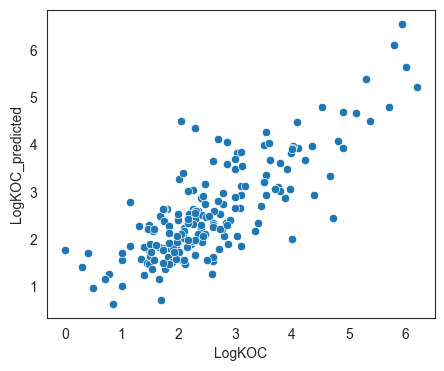

In [14]:
# Check performance
print(f"Train RMSE: {train_loss:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test R2: {test_r2:.4f}")
print(f'Test Distance: {knn_dist.mean()} \n')
y_test= test_df['LogKOC']

df_performance = pd.DataFrame({'LogKOC': y_test,
                        'LogKOC_predicted': y_pred,
                        'Error': np.abs(y_test - y_pred),
                        'kNN_Distance' : knn_dist
                        })


import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(5, 4))
sns.set_style('white')
sns.scatterplot(df_performance, x='LogKOC', y='LogKOC_predicted')
plt.show()

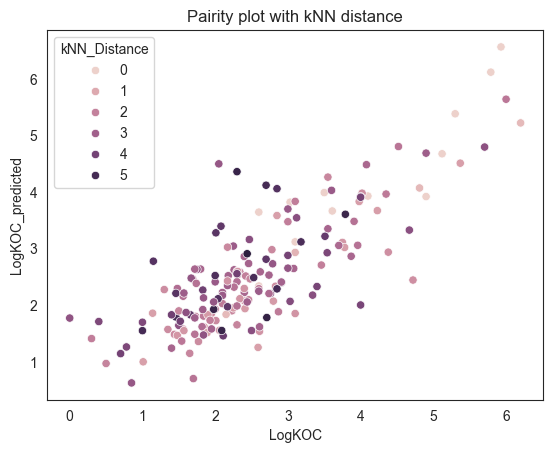

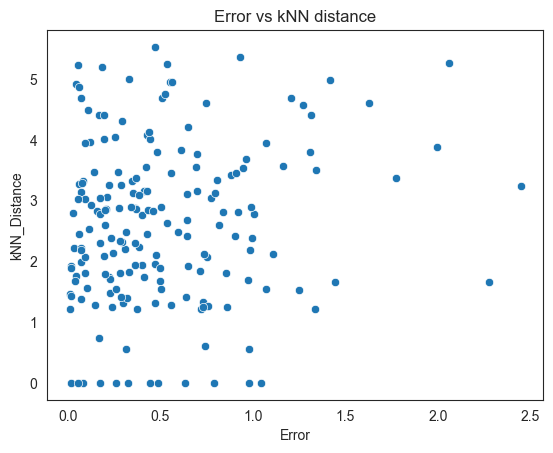

In [15]:
sns.scatterplot(df_performance, x='LogKOC', y='LogKOC_predicted', hue='kNN_Distance')
plt.title('Pairity plot with kNN distance')
plt.show()
sns.scatterplot(df_performance, x='Error', y='kNN_Distance')
plt.title('Error vs kNN distance')
plt.show()

### Uncertainty

In [16]:
# i) Mean and variance across trees
y_pred 
y_mean = y_pred.mean(axis=0)
y_std = y_pred.std(axis=0)

# ii) Quantiles from trees
# from the distribution of trees, we can further calculate quantiles
q_low, q_high = 0.1, 0.9 # 10% and 90% quantiles
qrf_lower = np.quantile(y_pred, q_low, axis=0)
qrf_upper = np.quantile(y_pred, q_high, axis=0)
qrf_mean = y_mean

df_test_pred = pd.DataFrame({
    "mean": y_mean,
    "std": y_std,
    "upper_quantile": qrf_upper,
    "lower_quantile": qrf_lower,
    "LogP": y_test,
    })


In [17]:
# Quantile RF (fixed interval)
below = (y_test >= qrf_lower) # true logP is above the lower prediction threshold
above = (y_test <= qrf_upper) # true logP is below the upper prediction threshold
# count how many times the true value is both above qrf_lower and below qrf_lower
# --> WITHIN the confidence interval
emp_cov_qrf = np.mean(below & above)
print('Empirical coverage of Quantile RF (10–90%)', emp_cov_qrf)


Empirical coverage of Quantile RF (10–90%) 0.7391304347826086


In [18]:
confidence = np.linspace(0.1, 0.9, 9) # confidence levels: 10%, 20%, ... , 90%


df_calibration = pd.DataFrame()

df_cal = pd.DataFrame()
df_cal['Nominal coverage'] = confidence
coverage = []
for c in confidence:
    z = norm.ppf(0.5 + c / 2) # z: multiplication factor for the standard deviation to obtain confidence interval limits
    # predictions below the lower confidence threshold mu-(z*std):
    below = (df_test_pred["LogP"] >= df_test_pred["mean"] - z*df_test_pred["std"]) 

    # predictions above the upper confidence threshold mu+(z*std):
    above = (df_test_pred["LogP"] <= df_test_pred["mean"] + z*df_test_pred["std"])
    coverage.append(np.mean(below & above))
df_cal['Empirical coverage'] = coverage
df_calibration = pd.concat([df_calibration, df_cal])

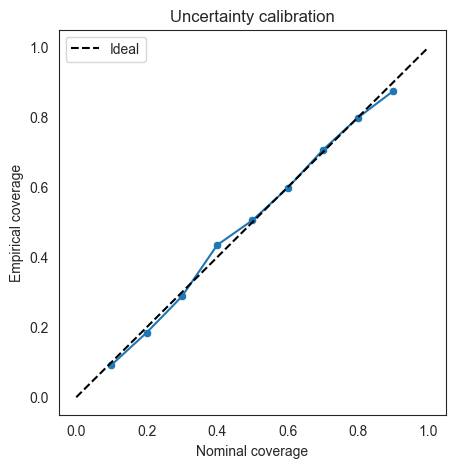

ECE : 0.0122


In [19]:
# Plot calibration curve
sns.set_style("white")
plt.figure(figsize=(5, 5))
sns.scatterplot(data=df_calibration, x='Nominal coverage', y='Empirical coverage', markers='o')
sns.lineplot(data=df_calibration, x='Nominal coverage', y='Empirical coverage', markers='o', legend=False)

plt.plot([0,1],[0,1],'--',label='Ideal', color='black')

plt.title("Uncertainty calibration")
plt.legend()
plt.show()

# calculate the Expected Calibration Error (ECE)
# ECE = 0: perfect calibration
# ECE > 0 : The smaller the ECE, the better the calibration
ece = np.mean(np.abs(df_calibration['Empirical coverage'] -  df_calibration['Nominal coverage']))
print(f"ECE : {ece:.4f}")

In [20]:
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test R2: {test_r2:.4f}")
print("OPERA RMSE: 0.61")
print("OPERA R2: 0.71")

Test RMSE: 0.6851
Test R2: 0.6406
OPERA RMSE: 0.61
OPERA R2: 0.71


#### Questions:
1) Which architecture did you choose, and why?
2) How well does your model perform on the test set? Could you outperform OPERA?
3) Did you add prediction uncertainty, and why? Are the uncertainties well calibrated?
4) Do you provide an AD, and why? How did you define your AD

1) Finetuning a pretrained model -> seyonec/ChemBERTa-zinc-base-v1 + regressor w/ one hidden layer
I felt like this was a good task for this model bc we used it in ex. 7A for LogS which is basically the same. and wanted more experience implementing this. I was unsure about the implentation though and nearly chose my favourite RF. I reduced to 5 Epochs bc of time. 

2) Model does not outperform OPERA, my results are not compareable. Vgl. oben, both OPERA values are better by .1 

3) Yes I did, I'ts quite close to the idel line, so good I guess. Covarage is okay, but under 80% (0.75) and the ECE is 0.01300 low. The uncertainty prediction gives information on how reliable this prediction is. 

4) Yes I did, used KNN (n=5). Honestly I'm not sure if this worked, I wasn't sure if I needed to scale the data / PCA and if I should run the fine tuning on scaled data? Or converted to smiles? Confused. As it is I converted the test / train data to maccs fp but not the data I put into the model, which is what is confusing me. I think a kernel density estimation could also be interesting and makes sense, but I had problems implementing it. 